In [1]:
# Install core deep learning and graph libraries
!pip install -q numpy>=1.26.0,<2.0.0 pandas scikit-learn matplotlib seaborn
!pip install -q torch==2.2.0 torchvision torchaudio
!pip install -q torch-geometric==2.5.0
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.2.0+cu121.html

# Install safety and inference wrappers
!pip install -q onnx==1.16.0 onnxruntime==1.17.0 mapie pydantic networkx

print("V3 Environment Setup Complete! (You may need to click 'Restart Session' in Colab if prompted)")

/bin/bash: line 1: 2.0.0: No such file or directory
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 849.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.5 MB/s e

In [2]:
!pip install "numpy<2.0.0" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you 

In [1]:
import os
import json
import logging
import warnings
import random
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from collections import defaultdict, Counter
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


# Set random seeds for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )

Training device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB


In [2]:
# Define data paths
DATA_PATH = "/content/dit-merged-complete.csv"
OUTPUT_DIR = Path("./training_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Dataset path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset path: /content/dit-merged-complete.csv
Output directory: training_outputs


In [3]:
class DataLoader_KubeHeal:
    """Load and explore dit-merged-complete.csv dataset."""

    @staticmethod
    def load_csv(path: str) -> pd.DataFrame:
        """Load CSV dataset."""
        df = pd.read_csv(path)
        logger.info(f"Loaded {len(df)} samples from {path}")
        return df

    @staticmethod
    def explore_dataset(df: pd.DataFrame):
        """Print dataset exploration statistics."""
        print("\n" + "=" * 80)
        print("DATASET EXPLORATION")
        print("=" * 80)
        print(f"\nDataset shape: {df.shape}")
        print(f"\nMissing values:\n{df.isnull().sum()}")

        # Label distribution
        if "operational_label" in df.columns:
            print(f"\nOperational Label Distribution:")
            print(df["operational_label"].value_counts())

        # Severity distribution
        if "severity" in df.columns:
            print(f"\nSeverity Distribution:")
            print(df["severity"].value_counts().sort_index())

        # Drift type distribution
        if "drift_type" in df.columns:
            print(f"\nDrift Type Distribution:")
            print(df["drift_type"].value_counts())

        print("\n" + "=" * 80)


# Load and explore dataset
print("Loading dataset...")
df = DataLoader_KubeHeal.load_csv(DATA_PATH)
DataLoader_KubeHeal.explore_dataset(df)

Loading dataset...

DATASET EXPLORATION

Dataset shape: (4782, 36)

Missing values:
timestamp                   0
app_name                    0
app_type                    0
namespace                   0
deployment                  0
scenario_family             0
scenario_name               0
drift_signature             0
drift_type                  0
magnitude                   0
num_drifts                  0
phase                       0
severity                    0
operational_label           0
repair_template_expected    0
request_rate                0
error_rate_5xx              0
latency_p99                 0
cpu_usage_cores             0
memory_working_set_bytes    0
sample_index                0
dedup_kept                  0
baseline_id                 0
collection_run_id           0
app_instance_count          0
notes                       0
baseline_json               0
live_json                   0
cpu_limit                   0
memory_limit                0
desired_replicas

In [4]:
class DITSecDataTransformer:
    """Transform CSV data into DIT-Sec model-ready format with extended features."""

    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler()
        self.class_weights = None
        self.feature_names = None
        self.drift_type_encoder = LabelEncoder()
        self.app_type_encoder = LabelEncoder()

    def parse_yaml_to_dict(self, yaml_str: str) -> Dict:
        """Parse YAML string to dictionary."""
        if not isinstance(yaml_str, str):
            return {}
        try:
            return json.loads(yaml_str.replace("'", '"'))
        except:
            return {}

    def extract_yaml_graph_features_extended(
        self, spec_dict: Dict, baseline_spec: Dict
    ) -> np.ndarray:
        """Extract 12D YAML graph features (Phase 2)."""
        if not spec_dict:
            spec_dict = {}
        if not baseline_spec:
            baseline_spec = {}

        def count_nodes(obj, depth=0, max_depth=[0]):
            count = 1
            max_depth[0] = max(max_depth[0], depth)
            if isinstance(obj, dict):
                count += sum(count_nodes(v, depth + 1, max_depth) for v in obj.values())
            elif isinstance(obj, list):
                count += sum(count_nodes(v, depth + 1, max_depth) for v in obj)
            return count

        def get_container_count(spec):
            return len(
                spec.get("spec", {})
                .get("template", {})
                .get("spec", {})
                .get("containers", [])
            )

        def get_volume_count(spec):
            return len(
                spec.get("spec", {})
                .get("template", {})
                .get("spec", {})
                .get("volumes", [])
            )

        def get_env_vars_total(spec):
            return sum(
                len(c.get("env", []))
                for c in spec.get("spec", {})
                .get("template", {})
                .get("spec", {})
                .get("containers", [])
            )

        def has_init_containers(spec):
            return float(
                len(
                    spec.get("spec", {})
                    .get("template", {})
                    .get("spec", {})
                    .get("initContainers", [])
                )
                > 0
            )

        def has_persistent_volumes(spec):
            volumes = (
                spec.get("spec", {})
                .get("template", {})
                .get("spec", {})
                .get("volumes", [])
            )
            return float(
                any(v.get("persistentVolumeClaim") is not None for v in volumes)
            )

        def count_resource_limits(spec):
            count = 0
            for container in (
                spec.get("spec", {})
                .get("template", {})
                .get("spec", {})
                .get("containers", [])
            ):
                if container.get("resources", {}).get("limits"):
                    count += 1
            return float(count)

        def count_security_context(spec):
            count = 0
            for container in (
                spec.get("spec", {})
                .get("template", {})
                .get("spec", {})
                .get("containers", [])
            ):
                if container.get("securityContext"):
                    count += 1
            return float(count)

        # Extract features
        node_count = float(count_nodes(spec_dict))
        max_d = [0]
        count_nodes(spec_dict, max_depth=max_d)
        depth = float(max_d[0])
        containers = float(get_container_count(spec_dict))
        volumes = float(get_volume_count(spec_dict))
        env_vars = float(get_env_vars_total(spec_dict))
        init_containers = has_init_containers(spec_dict)
        persistent_vols = has_persistent_volumes(spec_dict)
        resource_limits = count_resource_limits(spec_dict)
        security_contexts = count_security_context(spec_dict)

        # Baseline features for comparison (changes)
        baseline_containers = float(get_container_count(baseline_spec))
        baseline_volumes = float(get_volume_count(baseline_spec))

        # Features: 12D
        features = np.array(
            [
                node_count,
                depth,
                containers,
                volumes,
                env_vars,
                init_containers,
                persistent_vols,
                resource_limits,
                security_contexts,
                abs(containers - baseline_containers),  # container change
                abs(volumes - baseline_volumes),  # volume change
                float(node_count > 0),  # has_structure flag
            ],
            dtype=np.float32,
        )

        return features

    def extract_telemetry_with_deltas(self, row: pd.Series) -> np.ndarray:
        """Extract 14D telemetry features with deltas (Phase 2)."""
        # Original 7 features
        request_rate = float(row.get("request_rate", 0))
        latency_p99 = float(row.get("latency_p99", 0))
        cpu_usage = float(row.get("cpu_usage_cores", 0))
        memory_usage = float(row.get("memory_working_set_bytes", 0))
        error_rate = float(row.get("error_rate_5xx", 0))
        cpu_limit = float(row.get("cpu_limit", 0))
        memory_limit = float(row.get("memory_limit", 0))

        # Ratios/derived metrics (7 new features)
        cpu_ratio = cpu_usage / (cpu_limit + 1e-8)  # normalized capacity
        memory_ratio = memory_usage / (memory_limit + 1e-8)  # normalized capacity
        error_ratio = error_rate / (request_rate + 1e-8)  # error percentage
        critical_flag = float(
            (error_rate > 0.05) or (latency_p99 > 1000)
        )  # critical condition

        # Simple magnitude estimators (non-negative)
        latency_magnitude = np.log1p(latency_p99)  # log scale
        cpu_magnitude = np.log1p(cpu_usage)  # log scale
        memory_magnitude = np.log1p(memory_usage)  # log scale

        features = np.array(
            [
                request_rate,
                latency_p99,
                cpu_usage,
                memory_usage,
                error_rate,
                cpu_limit,
                memory_limit,
                cpu_ratio,
                memory_ratio,
                error_ratio,
                critical_flag,
                latency_magnitude,
                cpu_magnitude,
                memory_magnitude,
            ],
            dtype=np.float32,
        )

        return features

    def extract_drift_semantics(self, row: pd.Series) -> np.ndarray:
        """Extract 6D drift semantic features (Phase 2)."""
        # Drift type encoding
        drift_type = str(row.get("drift_type", "unknown"))
        drift_types = [
            "image",
            "replica",
            "config",
            "resource",
            "network",
            "other",
        ]
        drift_type_idx = (
            drift_types.index(drift_type)
            if drift_type in drift_types
            else drift_types.index("other")
        )
        drift_type_encoded = float(drift_type_idx)

        # Magnitude level (0-3)
        magnitude = str(row.get("magnitude", "unknown")).lower()
        magnitude_mapping = {"small": 1, "medium": 2, "large": 3, "critical": 4}
        magnitude_level = float(magnitude_mapping.get(magnitude, 1))

        # Number of concurrent drifts
        num_drifts = float(row.get("num_drifts", 1))

        # Severity level (already in data)
        severity = float(row.get("severity", 1))

        # Phase encoding (if available)
        phase = str(row.get("phase", "unknown"))
        phase_mapping = {"steady": 0, "degrading": 1, "recovering": 2}
        phase_encoded = float(phase_mapping.get(phase, 0))

        # Is rolling update (derived from drift_type)
        is_rolling = float("rolling" in drift_type.lower() or drift_type == "replica")

        features = np.array(
            [
                drift_type_encoded,
                magnitude_level,
                num_drifts,
                severity,
                phase_encoded,
                is_rolling,
            ],
            dtype=np.float32,
        )

        return features

    def transform(self) -> Tuple[List[Dict], Dict]:
        """Transform CSV to model-ready samples with 32D features."""
        samples = []
        stats = {
            "total_samples": len(self.df),
            "label_distribution": {},
            "severity_distribution": {},
            "feature_names": [],
        }

        # Encode labels
        if "operational_label" in self.df.columns:
            labels = self.label_encoder.fit_transform(self.df["operational_label"])
            stats["label_distribution"] = dict(
                zip(self.label_encoder.classes_, np.bincount(labels))
            )
        else:
            labels = np.zeros(len(self.df), dtype=int)

        # Compute class weights for imbalanced data
        unique_labels = np.unique(labels)
        class_weights = np.zeros(len(unique_labels))
        for idx, label in enumerate(unique_labels):
            class_weights[idx] = 1.0 / (np.sum(labels == label) + 1e-8)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32)

        # Extract severity distribution
        if "severity" in self.df.columns:
            stats["severity_distribution"] = dict(
                self.df["severity"].value_counts().sort_index()
            )

        # Build samples
        for idx, row in self.df.iterrows():
            # Parse YAML specs
            old_spec = self.parse_yaml_to_dict(row.get("baseline_json", "{}"))
            new_spec = self.parse_yaml_to_dict(row.get("live_json", "{}"))

            # Extract features (Phase 2: Extended)
            yaml_features = self.extract_yaml_graph_features_extended(
                new_spec, old_spec
            )
            telemetry_features = self.extract_telemetry_with_deltas(row)
            drift_semantics = self.extract_drift_semantics(row)

            sample = {
                "index": idx,
                "event_id": f"train-{idx}",
                "old_spec": old_spec,
                "new_spec": new_spec,
                "yaml_graph_features": yaml_features,  # 12D
                "telemetry_features": telemetry_features,  # 14D
                "drift_semantics": drift_semantics,  # 6D
                "severity": int(row.get("severity", 1)),
                "drift_type": str(row.get("drift_type", "unknown")),
                "drift_magnitude": str(row.get("magnitude", "unknown")),
                "operational_label": str(row.get("operational_label", "unknown")),
                "label_encoded": int(labels[idx]),
                "label": row.get("operational_label", "unknown"),
                "target": {
                    "namespace": str(row.get("namespace", "demo")),
                    "name": str(row.get("deployment", "app")),
                    "kind": "Deployment",
                },
            }
            samples.append(sample)

        stats["feature_names"] = [
            # YAML features (12D)
            "node_count",
            "depth",
            "containers",
            "volumes",
            "env_vars",
            "init_containers",
            "persistent_volumes",
            "resource_limits",
            "security_contexts",
            "container_change",
            "volume_change",
            "has_structure",
            # Telemetry features (14D)
            "request_rate",
            "latency_p99",
            "cpu_usage_cores",
            "memory_working_set_bytes",
            "error_rate_5xx",
            "cpu_limit",
            "memory_limit",
            "cpu_ratio",
            "memory_ratio",
            "error_ratio",
            "critical_flag",
            "latency_magnitude",
            "cpu_magnitude",
            "memory_magnitude",
            # Drift semantics (6D)
            "drift_type",
            "magnitude_level",
            "num_drifts",
            "severity",
            "phase",
            "is_rolling",
        ]

        return samples, stats


# Transform data
print("\nTransforming data (Phase 2: Extended features)...")
transformer = DITSecDataTransformer(df)
samples, transform_stats = transformer.transform()

print(f"Total samples: {transform_stats['total_samples']}")
print(f"Feature names ({len(transform_stats['feature_names'])}D):")
print(transform_stats["feature_names"])
print(f"\nLabel distribution:")
for label, count in transform_stats["label_distribution"].items():
    print(f"  {label}: {count}")



Transforming data (Phase 2: Extended features)...
Total samples: 4782
Feature names (32D):
['node_count', 'depth', 'containers', 'volumes', 'env_vars', 'init_containers', 'persistent_volumes', 'resource_limits', 'security_contexts', 'container_change', 'volume_change', 'has_structure', 'request_rate', 'latency_p99', 'cpu_usage_cores', 'memory_working_set_bytes', 'error_rate_5xx', 'cpu_limit', 'memory_limit', 'cpu_ratio', 'memory_ratio', 'error_ratio', 'critical_flag', 'latency_magnitude', 'cpu_magnitude', 'memory_magnitude', 'drift_type', 'magnitude_level', 'num_drifts', 'severity', 'phase', 'is_rolling']

Label distribution:
  Benign_Or_Subtle: 3392
  Harmful_Critical_Outage: 348
  Harmful_Multi_Vector: 86
  Harmful_Performance_Degradation: 903
  Harmful_Security_Breach: 53


In [5]:
def stratified_undersample(samples, labels, target_ratio=1.5):
    """
    Stratified undersampling: undersample majority, keep all minority.
    target_ratio: ratio of largest harmful to benign samples
    """
    # Count labels
    label_counts = Counter(labels)
    print("\nBefore undersampling:")
    for label_id, label_name in enumerate(transformer.label_encoder.classes_):
        count = label_counts.get(label_id, 0)
        print(f"  {label_name}: {count}")

    # Find largest minority class (excluding Benign)
    largest_minority = 0
    for label_id, count in label_counts.items():
        if label_id != 0:  # 0 is Benign
            largest_minority = max(largest_minority, count)

    # Target benign count
    target_benign = int(largest_minority * target_ratio)

    # Separate indices by label
    indices_by_label = defaultdict(list)
    for idx, label in enumerate(labels):
        indices_by_label[label].append(idx)

    # Build undersampled set
    undersampled_indices = []

    # Undersample benign
    benign_indices = indices_by_label[0]
    if len(benign_indices) > target_benign:
        undersampled_indices.extend(
            np.random.choice(benign_indices, size=target_benign, replace=False)
        )
    else:
        undersampled_indices.extend(benign_indices)

    # Keep all harmful
    for label_id in range(1, len(transformer.label_encoder.classes_)):
        undersampled_indices.extend(indices_by_label[label_id])

    # Shuffle
    undersampled_indices = list(np.random.permutation(undersampled_indices))

    # Filter samples
    undersampled_samples = [samples[i] for i in undersampled_indices]
    undersampled_labels = np.array([labels[i] for i in undersampled_indices])

    print("\nAfter undersampling:")
    new_label_counts = Counter(undersampled_labels)
    for label_id, label_name in enumerate(transformer.label_encoder.classes_):
        count = new_label_counts.get(label_id, 0)
        print(f"  {label_name}: {count}")

    return undersampled_samples, undersampled_labels


# Prepare labels
labels = np.array([s["label_encoded"] for s in samples])

# Apply stratified undersampling (Phase 1)
samples, labels = stratified_undersample(samples, labels, target_ratio=1.5)

# Train/val/test split (stratified)
train_samples, temp_samples, train_labels, temp_labels = train_test_split(
    samples, labels, test_size=0.2, random_state=42, stratify=labels
)

val_samples, test_samples, val_labels, test_labels = train_test_split(
    temp_samples, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(
    f"\nDataset split:"
    f"\n  Train: {len(train_samples)} samples"
    f"\n  Val: {len(val_samples)} samples"
    f"\n  Test: {len(test_samples)} samples"
)


Before undersampling:
  Benign_Or_Subtle: 3392
  Harmful_Critical_Outage: 348
  Harmful_Multi_Vector: 86
  Harmful_Performance_Degradation: 903
  Harmful_Security_Breach: 53

After undersampling:
  Benign_Or_Subtle: 1354
  Harmful_Critical_Outage: 348
  Harmful_Multi_Vector: 86
  Harmful_Performance_Degradation: 903
  Harmful_Security_Breach: 53

Dataset split:
  Train: 2195 samples
  Val: 274 samples
  Test: 275 samples


In [6]:
BATCH_SIZE = 64

class DriftDataset(Dataset):
    """PyTorch Dataset for drift detection."""

    def __init__(self, samples: List[Dict], split: str = "train"):
        self.samples = samples
        self.split = split

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # FIX: The CSV severity is 1, 2, 3. The Neural Network expects 0, 1, 2.
        # We subtract 1 here so the CUDA kernel doesn't crash out of bounds!
        safe_severity = max(0, int(sample["severity"]) - 1)

        return {
            "yaml_graph_features": torch.tensor(
                sample["yaml_graph_features"], dtype=torch.float32
            ),
            "telemetry_features": torch.tensor(
                sample["telemetry_features"], dtype=torch.float32
            ),
            "drift_semantics": torch.tensor(
                sample["drift_semantics"], dtype=torch.float32
            ),
            "label": torch.tensor(sample["label_encoded"], dtype=torch.long),
            "severity": torch.tensor(safe_severity, dtype=torch.long),
        }

# Create datasets
train_dataset = DriftDataset(train_samples, "train")
val_dataset = DriftDataset(val_samples, "val")
test_dataset = DriftDataset(test_samples, "test")

# Class-weighted sampler for balanced batch sampling
train_labels_arr = np.array([s["label_encoded"] for s in train_samples])
class_counts = np.bincount(
    train_labels_arr, minlength=len(transformer.label_encoder.classes_)
)
class_weights_sampler = 1.0 / (class_counts + 1e-8)
sample_weights = class_weights_sampler[train_labels_arr]

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(train_samples), replacement=True
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=0,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(
    f"DataLoaders created:"
    f"\n  Train: {len(train_loader)} batches"
    f"\n  Val: {len(val_loader)} batches"
    f"\n  Test: {len(test_loader)} batches"
)

DataLoaders created:
  Train: 35 batches
  Val: 5 batches
  Test: 5 batches


In [7]:
class FocalLoss(nn.Module):
    """Focal Loss for class imbalance (Phase 1 improvement)."""

    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        Args:
            inputs: (N, C) logits
            targets: (N,) long tensor
        """
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        p = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - p) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss

In [8]:
class DITSecModel_Enhanced(nn.Module):
    """
    Enhanced DIT-Sec v3.0 model with:
    - Phase 2: 32D feature input (12D YAML + 14D telemetry + 6D drift semantics)
    - Phase 3: Deeper encoders with residual connection + Auxiliary severity task
    """

    def __init__(
        self,
        yaml_feature_dim: int = 12,
        telemetry_feature_dim: int = 14,
        drift_semantics_dim: int = 6,
        hidden_dim: int = 128,
        num_classes: int = 5,
        num_severity_levels: int = 3,
        dropout: float = 0.35,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes

        # YAML Graph Encoder
        self.yaml_encoder = nn.Sequential(
            nn.Linear(yaml_feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )

        # Telemetry Encoder
        self.telemetry_encoder = nn.Sequential(
            nn.Linear(telemetry_feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )

        # Drift Semantics Encoder
        self.drift_encoder = nn.Sequential(
            nn.Linear(drift_semantics_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, hidden_dim // 2),
            nn.ReLU(),
        )

        # Multi-Head Cross-Attention fusion
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True
        )

        # Fusion MLP
        fusion_input_dim = hidden_dim * 2 + hidden_dim // 2
        self.fusion_mlp = nn.Sequential(
            nn.Linear(fusion_input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
        )

        # The Two Output Heads required by the Training Loop
        self.classifier = nn.Linear(hidden_dim // 2, num_classes)
        self.severity_head = nn.Linear(hidden_dim // 2, num_severity_levels)

    def forward(self, yaml_features, telemetry_features, drift_semantics):
        # 1. Encode Modalities
        y = self.yaml_encoder(yaml_features)
        t = self.telemetry_encoder(telemetry_features)
        d = self.drift_encoder(drift_semantics)

        # 2. Cross-Attention Fusion (YAML queries Telemetry)
        # We add dummy sequence lengths for standard Linear features
        y_seq = y.unsqueeze(1)
        t_seq = t.unsqueeze(1)

        attn_out, _ = self.attention(query=y_seq, key=t_seq, value=t_seq)
        attn_out = attn_out.squeeze(1)

        # 3. Concatenate all features (Original encoded + Attention output + Drift)
        fused = torch.cat([attn_out, t, d], dim=1)

        # 4. Pass through final MLP
        final_embedding = self.fusion_mlp(fused)

        # 5. Output Multi-Task Logits
        class_logits = self.classifier(final_embedding)
        severity_logits = self.severity_head(final_embedding)

        return class_logits, severity_logits

# Initialize the model right after defining the class so Cell 10 doesn't fail
model = DITSecModel_Enhanced().to(device)

In [9]:
# Phase 1: Focal Loss instead of weighted CrossEntropyLoss
criterion_classification = FocalLoss(alpha=0.25, gamma=2.0)

# Phase 3: Auxiliary severity loss
criterion_severity = nn.CrossEntropyLoss()

# Optimizer with L2 regularization (Phase 3)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler with warmup
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

# Training configuration (Phase 1-3)
EPOCHS = 150  # Increased from 100
EARLY_STOPPING_PATIENCE = 25  # Increased from 15
early_stopping_counter = 0
best_val_f1 = 0.0  # Changed from best_val_loss (Phase 1)
best_model_path = OUTPUT_DIR / "best_model.pth"

# Metrics tracking
train_history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
    "learning_rate": [],
}

print("\nTraining configuration (Phase 1-3):")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: 1e-4")
print(f"  Optimizer: AdamW (weight_decay=1e-4)")
print(f"  Loss: Focal Loss (Phase 1) + Auxiliary severity (Phase 3)")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  Early stopping metric: Weighted F1 (Phase 1)")
print(f"  Device: {device}")


Training configuration (Phase 1-3):
  Epochs: 150
  Batch size: 64
  Learning rate: 1e-4
  Optimizer: AdamW (weight_decay=1e-4)
  Loss: Focal Loss (Phase 1) + Auxiliary severity (Phase 3)
  Early stopping patience: 25
  Early stopping metric: Weighted F1 (Phase 1)
  Device: cuda


In [10]:
def train_epoch(
    epoch: int,
    model,
    loader,
    optimizer,
    criterion_cls,
    criterion_sev,
    device,
):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    for batch_idx, batch in enumerate(loader):
        yaml_features = batch["yaml_graph_features"].to(device)
        telemetry_features = batch["telemetry_features"].to(device)
        drift_semantics = batch["drift_semantics"].to(device)
        labels = batch["label"].to(device)
        severity = batch["severity"].to(device)

        # Forward pass
        logits, severity_logits = model(
            yaml_features, telemetry_features, drift_semantics
        )

        # Phase 1: Focal Loss for classification
        loss_cls = criterion_cls(logits, labels)

        # Phase 3: Auxiliary severity loss (lightweight)
        loss_sev = criterion_sev(severity_logits, severity)

        # Combined loss
        loss = loss_cls + 0.2 * loss_sev

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx + 1}/{len(loader)}: loss={loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    f1_weighted = f1_score(
        all_labels, all_predictions, average="weighted", zero_division=0
    )

    return avg_loss, accuracy, f1_weighted


def validate(
    model,
    loader,
    criterion_cls,
    criterion_sev,
    device,
):
    """Validate model."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            yaml_features = batch["yaml_graph_features"].to(device)
            telemetry_features = batch["telemetry_features"].to(device)
            drift_semantics = batch["drift_semantics"].to(device)
            labels = batch["label"].to(device)
            severity = batch["severity"].to(device)

            logits, severity_logits = model(
                yaml_features, telemetry_features, drift_semantics
            )

            loss_cls = criterion_cls(logits, labels)
            loss_sev = criterion_sev(severity_logits, severity)
            loss = loss_cls + 0.2 * loss_sev

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    f1_weighted = f1_score(
        all_labels, all_predictions, average="weighted", zero_division=0
    )

    return avg_loss, accuracy, f1_weighted, all_predictions, all_labels


# Training loop
print("\n" + "=" * 80)
print("TRAINING STARTED (Phase 1-3)")
print("=" * 80)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    # Train
    train_loss, train_acc, train_f1 = train_epoch(
        epoch,
        model,
        train_loader,
        optimizer,
        criterion_classification,
        criterion_severity,
        device,
    )

    # Validate
    val_loss, val_acc, val_f1, _, _ = validate(
        model, val_loader, criterion_classification, criterion_severity, device
    )

    # Schedule step
    scheduler.step()

    # Log metrics
    train_history["epoch"].append(epoch + 1)
    train_history["train_loss"].append(train_loss)
    train_history["train_accuracy"].append(train_acc)
    train_history["train_f1"].append(train_f1)
    train_history["val_loss"].append(val_loss)
    train_history["val_accuracy"].append(val_acc)
    train_history["val_f1"].append(val_f1)
    train_history["learning_rate"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train F1: {train_f1:.4f}"
    )
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")

    # Early stopping based on F1 (Phase 1 change)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        early_stopping_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"✓ Best model saved (val_f1: {val_f1:.4f})")
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs")
            break


TRAINING STARTED (Phase 1-3)

Epoch 1/150
  Batch 10/35: loss=0.4714
  Batch 20/35: loss=0.4761
  Batch 30/35: loss=0.4224
Train Loss: 0.4624, Train Acc: 29.16%, Train F1: 0.2693
Val Loss: 0.4237, Val Acc: 53.28%, Val F1: 0.5725
Learning Rate: 9.89e-05
✓ Best model saved (val_f1: 0.5725)

Epoch 2/150
  Batch 10/35: loss=0.4149
  Batch 20/35: loss=0.4432
  Batch 30/35: loss=0.3629
Train Loss: 0.4091, Train Acc: 42.87%, Train F1: 0.4045
Val Loss: 0.3623, Val Acc: 76.28%, Val F1: 0.7680
Learning Rate: 9.57e-05
✓ Best model saved (val_f1: 0.7680)

Epoch 3/150
  Batch 10/35: loss=0.3843
  Batch 20/35: loss=0.3428
  Batch 30/35: loss=0.3677
Train Loss: 0.3655, Train Acc: 51.21%, Train F1: 0.4890
Val Loss: 0.3249, Val Acc: 75.18%, Val F1: 0.7543
Learning Rate: 9.05e-05

Epoch 4/150
  Batch 10/35: loss=0.3281
  Batch 20/35: loss=0.3133
  Batch 30/35: loss=0.3191
Train Loss: 0.3286, Train Acc: 59.95%, Train F1: 0.5885
Val Loss: 0.2956, Val Acc: 78.10%, Val F1: 0.7834
Learning Rate: 8.36e-05
✓ 

In [11]:
print("\n" + "=" * 80)
print("EVALUATION ON TEST SET")
print("=" * 80)

# Load best model
model.load_state_dict(torch.load(best_model_path, weights_only=True))

# Test evaluation
model.eval()
all_test_predictions = []
all_test_labels = []
all_test_probs = []

with torch.no_grad():
    for batch in test_loader:
        yaml_features = batch["yaml_graph_features"].to(device)
        telemetry_features = batch["telemetry_features"].to(device)
        drift_semantics = batch["drift_semantics"].to(device)
        labels = batch["label"].to(device)

        logits, _ = model(yaml_features, telemetry_features, drift_semantics)

        probs = F.softmax(logits, dim=1)
        _, predicted = logits.max(1)

        all_test_predictions.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())
        all_test_probs.extend(probs.cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_labels = np.array(all_test_labels)
all_test_probs = np.array(all_test_probs)

# Calculate metrics
test_accuracy = accuracy_score(all_test_labels, all_test_predictions)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    all_test_labels, all_test_predictions, average="weighted", zero_division=0
)
test_roc_auc = roc_auc_score(
    all_test_labels, all_test_probs, multi_class="ovr", average="weighted"
)

print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Test Precision (weighted): {test_precision:.4f}")
print(f"Test Recall (weighted): {test_recall:.4f}")
print(f"Test F1 (weighted): {test_f1:.4f}")
print(f"Test ROC-AUC (weighted): {test_roc_auc:.4f}")

# Per-class metrics
print("\nPer-class metrics:")
precision, recall, f1, support = precision_recall_fscore_support(
    all_test_labels, all_test_predictions, average=None, zero_division=0
)

for idx, class_name in enumerate(transformer.label_encoder.classes_):
    print(
        f"  {class_name}: Precision={precision[idx]:.4f}, Recall={recall[idx]:.4f}, F1={f1[idx]:.4f}, Support={support[idx]}"
    )

# Confusion matrix
cm = confusion_matrix(all_test_labels, all_test_predictions)

print("\nConfusion Matrix:")
print(cm)

# Save metrics
metrics_summary = {
    "test_accuracy": float(test_accuracy),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
    "test_roc_auc": float(test_roc_auc),
    "per_class_metrics": {},
}

for idx, class_name in enumerate(transformer.label_encoder.classes_):
    metrics_summary["per_class_metrics"][class_name] = {
        "precision": float(precision[idx]),
        "recall": float(recall[idx]),
        "f1": float(f1[idx]),
        "support": int(support[idx]),
    }

with open(OUTPUT_DIR / "metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

# Save label mapping
label_mapping = {
    str(i): label for i, label in enumerate(transformer.label_encoder.classes_)
}
with open(OUTPUT_DIR / "label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=2)

# Save training history
history_df = pd.DataFrame(train_history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)


EVALUATION ON TEST SET

Test Accuracy: 0.9418 (94.18%)
Test Precision (weighted): 0.9686
Test Recall (weighted): 0.9418
Test F1 (weighted): 0.9489
Test ROC-AUC (weighted): 0.9974

Per-class metrics:
  Benign_Or_Subtle: Precision=1.0000, Recall=1.0000, F1=1.0000, Support=136
  Harmful_Critical_Outage: Precision=0.9130, Recall=0.6000, F1=0.7241, Support=35
  Harmful_Multi_Vector: Precision=0.8000, Recall=1.0000, F1=0.8889, Support=8
  Harmful_Performance_Degradation: Precision=1.0000, Recall=1.0000, F1=1.0000, Support=91
  Harmful_Security_Breach: Precision=0.2000, Recall=0.6000, F1=0.3000, Support=5

Confusion Matrix:
[[136   0   0   0   0]
 [  0  21   2   0  12]
 [  0   0   8   0   0]
 [  0   0   0  91   0]
 [  0   2   0   0   3]]



Training curves saved to training_outputs/training_curves.png
Confusion matrix saved to training_outputs/confusion_matrix.png


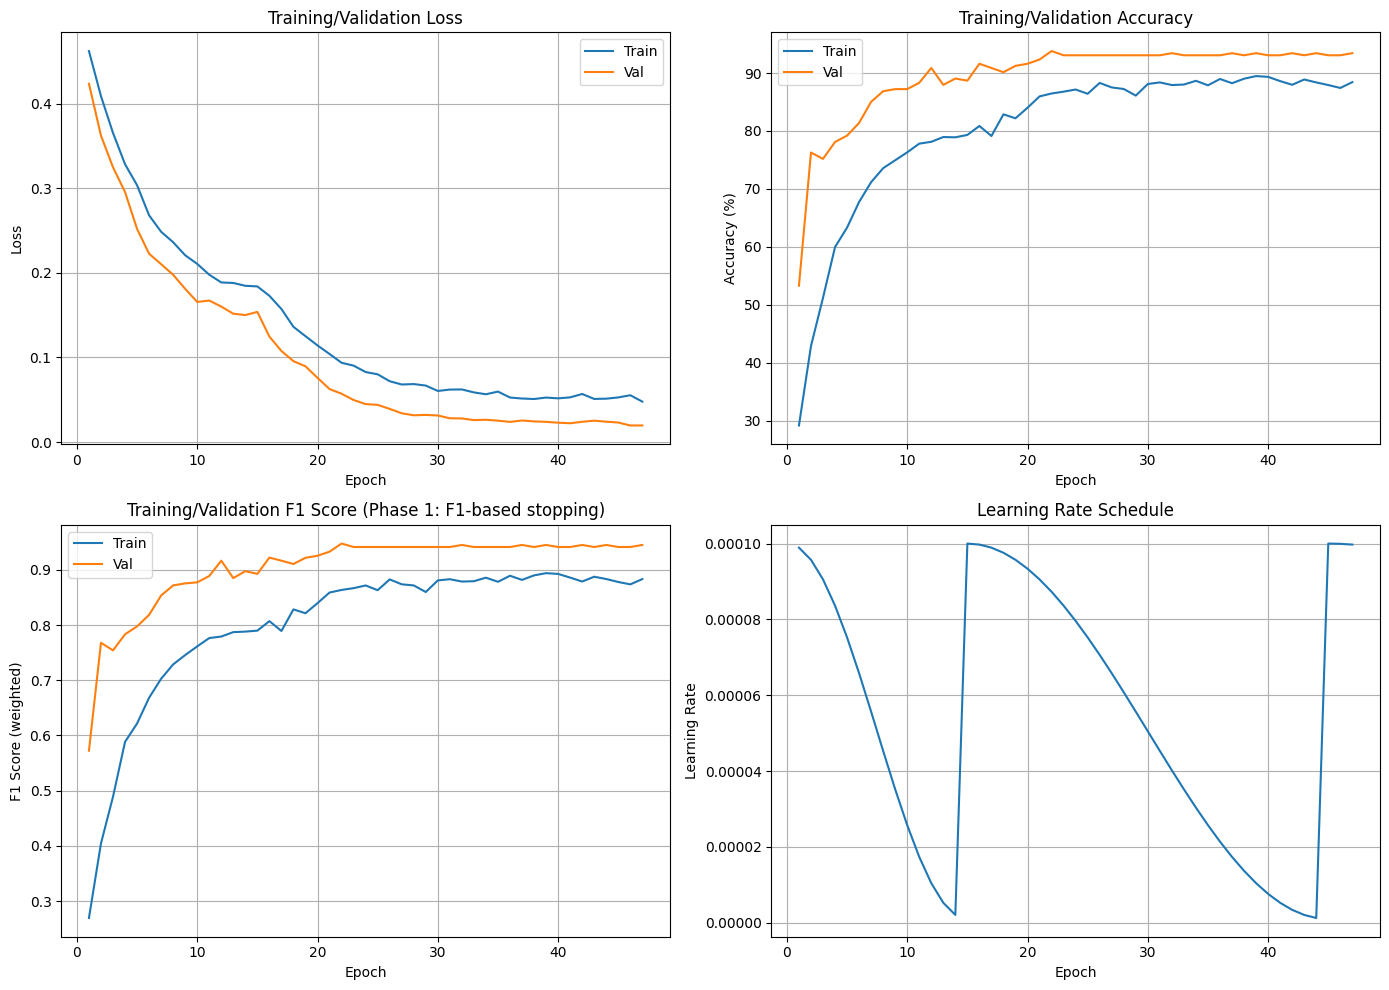

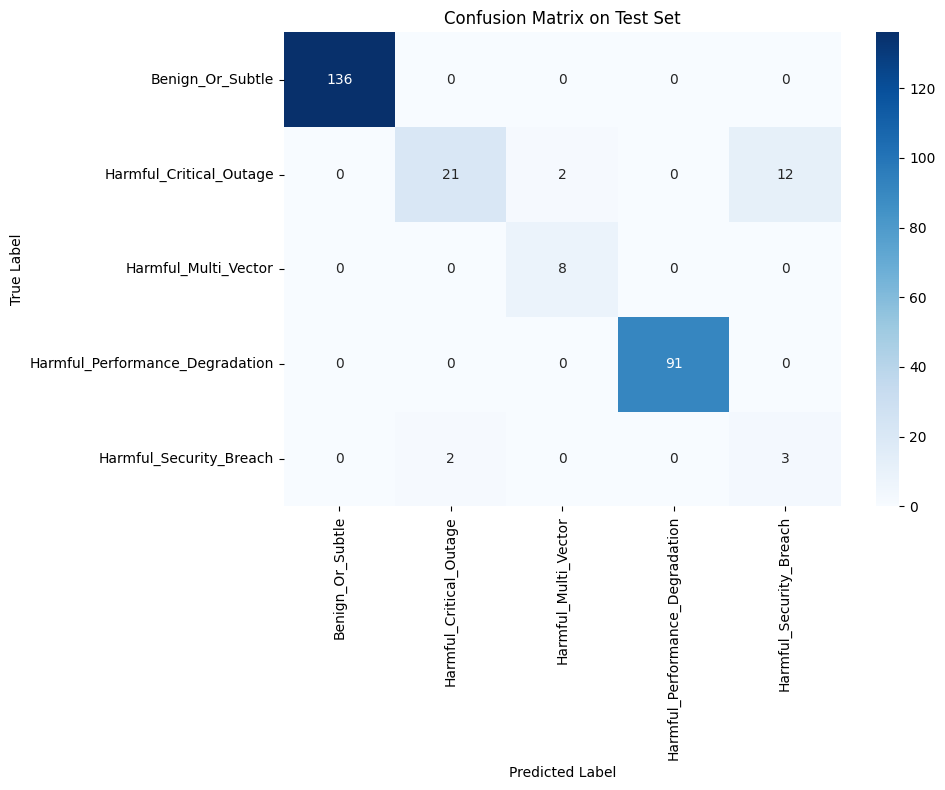

In [12]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_history["epoch"], train_history["train_loss"], label="Train")
axes[0, 0].plot(train_history["epoch"], train_history["val_loss"], label="Val")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Training/Validation Loss")
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].plot(train_history["epoch"], train_history["train_accuracy"], label="Train")
axes[0, 1].plot(train_history["epoch"], train_history["val_accuracy"], label="Val")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].set_title("Training/Validation Accuracy")
axes[0, 1].legend()
axes[0, 1].grid()

axes[1, 0].plot(train_history["epoch"], train_history["train_f1"], label="Train")
axes[1, 0].plot(train_history["epoch"], train_history["val_f1"], label="Val")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("F1 Score (weighted)")
axes[1, 0].set_title("Training/Validation F1 Score (Phase 1: F1-based stopping)")
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].plot(train_history["epoch"], train_history["learning_rate"])
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Learning Rate")
axes[1, 1].set_title("Learning Rate Schedule")
axes[1, 1].grid()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
print(f"\nTraining curves saved to {OUTPUT_DIR / 'training_curves.png'}")

# Confusion matrix visualization
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=transformer.label_encoder.classes_,
    yticklabels=transformer.label_encoder.classes_,
)
plt.title("Confusion Matrix on Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
print(f"Confusion matrix saved to {OUTPUT_DIR / 'confusion_matrix.png'}")

In [13]:
# Save checkpoint
torch.save(model.state_dict(), OUTPUT_DIR / "dit_sec_v3_checkpoint.pth")
print(f"\nModel checkpoint saved to {OUTPUT_DIR / 'dit_sec_v3_checkpoint.pth'}")

# Summary
print("\n" + "=" * 80)
print("TRAINING COMPLETE (Phase 1-3)")
print("=" * 80)
print(f"\nPhase 1: Class Balancing + Focal Loss + Batch Sampling")
print(f"  - Undersampled to ~{len(train_samples)} training samples")
print(f"  - Focal Loss with α=0.25, γ=2.0")
print(f"  - Class-weighted batch sampler")
print(f"\nPhase 2: Extended Features (32D)")
print(f"  - YAML features: 12D (graph structure + change detection)")
print(f"  - Telemetry features: 14D (metrics + ratios + deltas)")
print(f"  - Drift semantics: 6D (drift type, magnitude, severity, phase)")
print(f"\nPhase 3: Enhanced Model Architecture")
print(f"  - Deeper encoders (128 hidden dim)")
print(f"  - Wider feature processing (12D+14D→128)")
print(f"  - Auxiliary severity task (multi-task learning)")
print(f"  - Improved regularization (L2, dropout=0.35)")
print(f"\nResults:")
print(f"  Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"  Test F1 (weighted): {test_f1:.4f}")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
print(f"\nArtifacts:")
print(f"  ✓ Model checkpoint: {best_model_path}")
print(f"  ✓ Training history: {OUTPUT_DIR / 'training_history.csv'}")
print(f"  ✓ Metrics: {OUTPUT_DIR / 'metrics_summary.json'}")
print(f"  ✓ Label mapping: {OUTPUT_DIR / 'label_mapping.json'}")
print(
    f"  ✓ Visualizations: {OUTPUT_DIR / 'training_curves.png'}, {OUTPUT_DIR / 'confusion_matrix.png'}"
)
print("\n" + "=" * 80)


Model checkpoint saved to training_outputs/dit_sec_v3_checkpoint.pth

TRAINING COMPLETE (Phase 1-3)

Phase 1: Class Balancing + Focal Loss + Batch Sampling
  - Undersampled to ~2195 training samples
  - Focal Loss with α=0.25, γ=2.0
  - Class-weighted batch sampler

Phase 2: Extended Features (32D)
  - YAML features: 12D (graph structure + change detection)
  - Telemetry features: 14D (metrics + ratios + deltas)
  - Drift semantics: 6D (drift type, magnitude, severity, phase)

Phase 3: Enhanced Model Architecture
  - Deeper encoders (128 hidden dim)
  - Wider feature processing (12D+14D→128)
  - Auxiliary severity task (multi-task learning)
  - Improved regularization (L2, dropout=0.35)

Results:
  Test Accuracy: 94.18%
  Test F1 (weighted): 0.9489
  Test ROC-AUC: 0.9974

Artifacts:
  ✓ Model checkpoint: training_outputs/best_model.pth
  ✓ Training history: training_outputs/training_history.csv
  ✓ Metrics: training_outputs/metrics_summary.json
  ✓ Label mapping: training_outputs/labe